In [ ]:
!pip install -q optuna catboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

In [ ]:
import wordcloud

# EDA

In [ ]:
df = pd.read_csv("/content/tweets.csv")
df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [ ]:
df.isna().sum()

,0
id,0
keyword,0
location,3418
text,0
target,0


<Axes: xlabel='target', ylabel='count'>

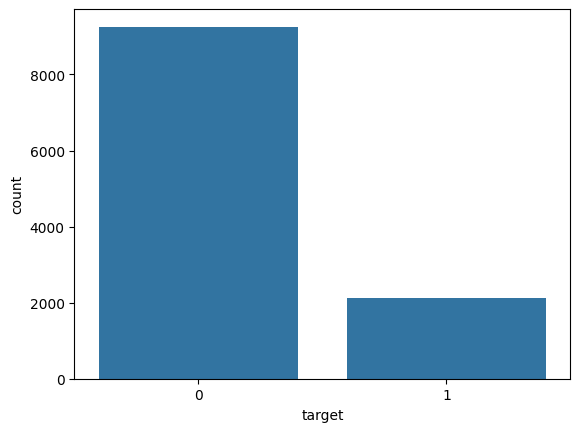

In [ ]:
sns.countplot(data=df, x='target')

<Axes: xlabel='keyword', ylabel='text'>

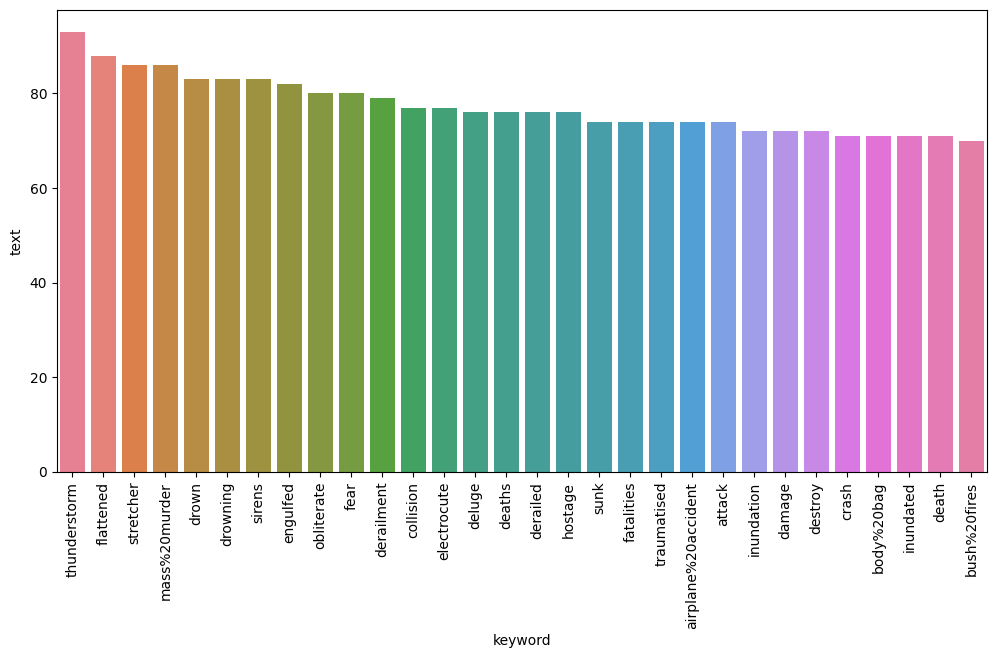

In [ ]:
df_bar = df.groupby(by='keyword').count().reset_index()
df_bar = df_bar.sort_values(by='text', ascending=False)[['keyword', 'text', 'location']]
df_bar = df_bar.head(30)
df_bar
plt.figure(figsize=(12, 6))
plt.xticks(rotation=90)
sns.barplot(data=df_bar, x='keyword', y='text', hue='keyword')

<Axes: xlabel='location', ylabel='target'>

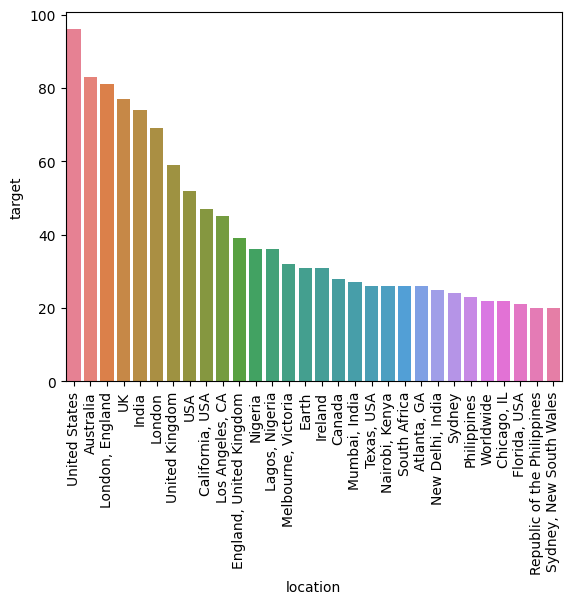

In [ ]:
df_c = df['location'].value_counts().reset_index()
df_c.columns = ['location', 'target']
df_c = df_c.head(30)
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df_c, x='location', y='target', hue='location')

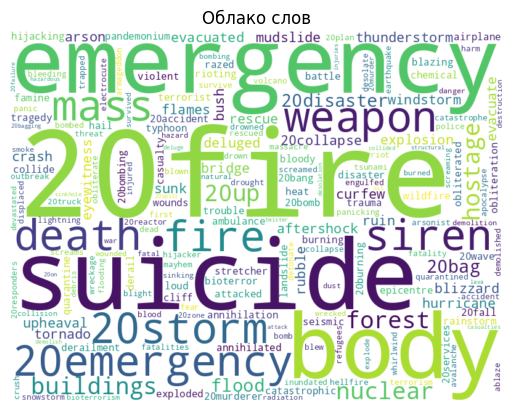

In [ ]:
words = list(set(df['keyword']))
wc = wordcloud.WordCloud(background_color='white', height=600, width=800).generate(" ".join(words))
plt.figure()
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Облако слов")
plt.show()

In [ ]:
import nltk
from nltk import ngrams
from nltk.tokenize import word_tokenize
from collections import Counter
from nltk.corpus import stopwords
import string

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
def clean_bigrams(bigrams):
    cleaned = []

    for (word1, word2), count in bigrams:
        if '...' in word1 or '...' in word2:
            continue
        if '…' in word1 or '…' in word2:
            continue

        if 'http' in word1.lower() or 'http' in word2.lower():
            continue

        if "'" in word1 or "'" in word2:
            continue

        if len(word1) < 2 or len(word2) < 2:
            continue

        if not (word1.isalpha() and word2.isalpha()):
            continue

        cleaned.append(((word1, word2), count))

    return cleaned

In [ ]:
sw = set(stopwords.words('english'))
sp = set(string.punctuation)
useless_words = ['https']

In [ ]:
all_words = " ".join(list(df['text'])).lower()
norm = word_tokenize(all_words)
norm = [i for i in norm if i not in sw and i not in sp]
bigrams = Counter(ngrams(norm, n=2))
bigrams = sorted(list(bigrams.items()), key=lambda x: x[1], reverse=True)[:40]
bigrams = clean_bigrams(bigrams)
bigrams

[(('taal', 'volcano'), 86),
 (('gon', 'na'), 62),
 (('climate', 'change'), 49),
 (('years', 'ago'), 48),
 (('emergency', 'services'), 43),
 (('puerto', 'rico'), 40),
 (('bush', 'fires'), 40),
 (('mass', 'murder'), 39),
 (('severe', 'thunderstorm'), 39),
 (('body', 'bags'), 38),
 (('five', 'years'), 38),
 (('swallows', 'bus'), 37),
 (('freight', 'train'), 37),
 (('dust', 'storm'), 37),
 (('heat', 'wave'), 37),
 (('thunderstorm', 'warning'), 37),
 (('schools', 'brace'), 35),
 (('triumphant', 'party'), 35),
 (('party', 'gove'), 35),
 (('gove', 'heart'), 35),
 (('suicide', 'bombing'), 34),
 (('brace', 'five'), 34),
 (('years', 'upheaval'), 34),
 (('upheaval', 'triumphant'), 34),
 (('first', 'responders'), 31)]

<Axes: title={'center': 'Самы распространенные биграммы'}>

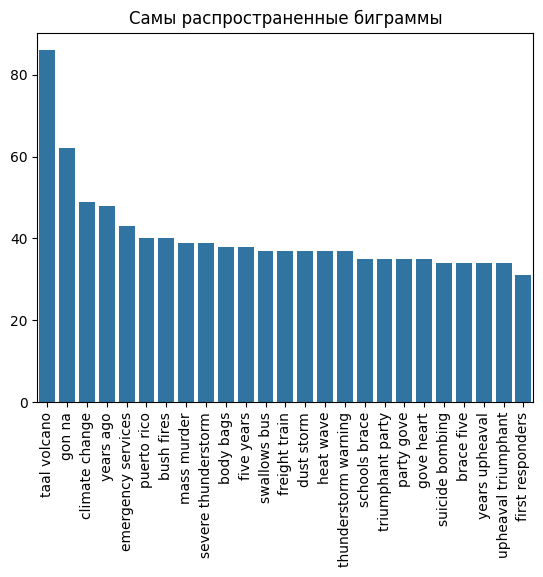

In [ ]:
plt.figure()
plt.title("Самы распространенные биграммы")
plt.xticks(rotation=90)
sns.barplot(x=[" ".join(i[0]) for i in bigrams], y=[i[1] for i in bigrams])

# Применяем бустинг

In [ ]:
df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [ ]:
def detect_http(t): return t.count('http')
def detect_hastag(t): return t.count('#')
def detect_mentions(t): return t.count('@')
def detect_len(t): return len(t)
def detect_unique_words(t): return len(set(t.split()))

df['http_count'] = df['text'].apply(detect_http)
df['ht_count'] = df['text'].apply(detect_hastag)
df['ment_count'] = df['text'].apply(detect_mentions)
df['len_count'] = df['text'].apply(detect_len)
df['unique_words'] = df['text'].apply(detect_unique_words)

df.head()

,id,keyword,location,text,target,http_count,ht_count,ment_count,len_count,unique_words
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1,0,0,0,125,16
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1,0,0,0,131,22
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1,1,0,0,63,7
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1,2,0,0,87,8
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0,1,0,0,140,19


In [ ]:
x = df.drop(['target', 'id', 'keyword', 'location'], axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((9096, 6), (2274, 6), (9096,), (2274,))

In [ ]:
scaler = StandardScaler()
extra_x_train = x_train[['http_count', 'ht_count', 'ment_count', 'len_count', 'unique_words']]
extra_x_test = x_test[['http_count', 'ht_count', 'ment_count', 'len_count', 'unique_words']]

x_train = x_train['text']
x_test = x_test['text']

extra_x_train = scaler.fit_transform(extra_x_train)
extra_x_test = scaler.transform(extra_x_test)

x_train.shape, x_test.shape

((9096,), (2274,))

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('intfloat/multilingual-e5-base')
emb_x_train = model.encode(x_train.values, convert_to_numpy=True)
emb_x_test = model.encode(x_test.values, convert_to_numpy=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from scipy.sparse import hstack, csr_matrix

In [ ]:
tf = TfidfVectorizer(stop_words='english', max_features=10_000)
x_train = tf.fit_transform(x_train)
x_test = tf.transform(x_test)
x_train.shape, x_test.shape

((9096, 10000), (2274, 10000))

In [ ]:
x_train = hstack([x_train, csr_matrix(extra_x_train), csr_matrix(emb_x_train)])
x_test = hstack([x_test, csr_matrix(extra_x_test), csr_matrix(emb_x_test)])
x_train.shape, x_test.shape

((9096, 10773), (2274, 10773))

In [ ]:
model = CatBoostClassifier(auto_class_weights='Balanced')
model.fit(x_train, y_train)
preds = model.predict(x_test)

Learning rate set to 0.026446
0:	learn: 0.6831419	total: 348ms	remaining: 5m 47s
1:	learn: 0.6756568	total: 637ms	remaining: 5m 17s
2:	learn: 0.6673246	total: 912ms	remaining: 5m 3s
3:	learn: 0.6585209	total: 1.19s	remaining: 4m 56s
4:	learn: 0.6518505	total: 1.5s	remaining: 4m 57s
5:	learn: 0.6448631	total: 1.77s	remaining: 4m 53s
6:	learn: 0.6377123	total: 2.04s	remaining: 4m 50s
7:	learn: 0.6310402	total: 2.33s	remaining: 4m 48s
8:	learn: 0.6233556	total: 2.61s	remaining: 4m 47s
9:	learn: 0.6169743	total: 2.88s	remaining: 4m 45s
10:	learn: 0.6118378	total: 3.15s	remaining: 4m 43s
11:	learn: 0.6061721	total: 3.43s	remaining: 4m 42s
12:	learn: 0.6004882	total: 3.72s	remaining: 4m 42s
13:	learn: 0.5942439	total: 3.99s	remaining: 4m 41s
14:	learn: 0.5879295	total: 4.29s	remaining: 4m 41s
15:	learn: 0.5822590	total: 4.58s	remaining: 4m 41s
16:	learn: 0.5771007	total: 4.86s	remaining: 4m 40s
17:	learn: 0.5732409	total: 5.13s	remaining: 4m 39s
18:	learn: 0.5677192	total: 5.4s	remaining: 4m

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, PrecisionRecallDisplay

In [ ]:
cr = classification_report(y_test, preds)
print(cr)

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1857
           1       0.71      0.76      0.74       417

    accuracy                           0.90      2274
   macro avg       0.83      0.85      0.84      2274
weighted avg       0.90      0.90      0.90      2274



In [ ]:
cm = confusion_matrix(y_test, preds)

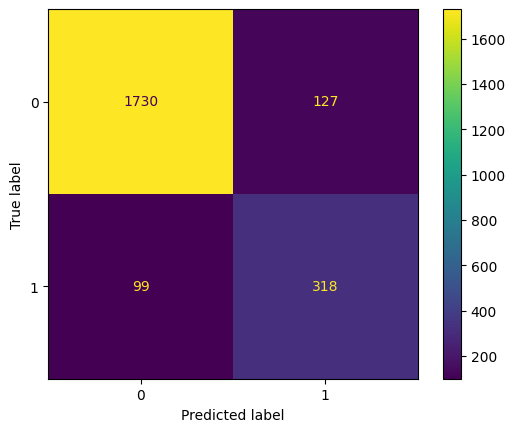

In [ ]:
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

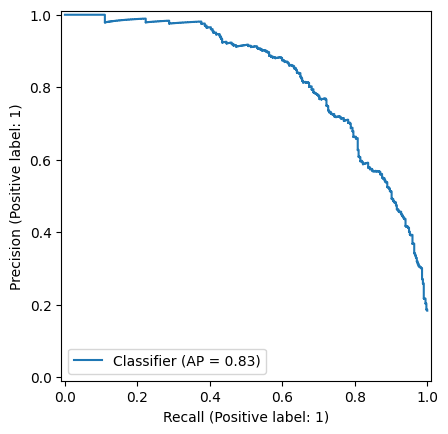

In [ ]:
preds_pr = model.predict_proba(x_test)[:, 1]
PrecisionRecallDisplay.from_predictions(y_test, preds_pr)